In [24]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import roc_curve,auc
from sklearn.metrics import precision_score,recall_score,accuracy_score

In [23]:
x,y=make_classification(n_samples=1000,n_features=10,n_redundant=5,n_informative=5,n_classes=2,random_state=42)
df=pd.DataFrame(x)
display(df)
display(df.columns)
display(x)
display(len(y))
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
display(x_train.shape)
classifier=LogisticRegression()
classifier.fit(x_train,y_train)
y_pred=classifier.predict(x_test)
display(confusion_matrix(y_test,y_pred))
report=classification_report(y_test,y_pred)
print(report)
y_pred_proba=classifier.predict_proba(x_test)[:,1]

,0,1,2,3,4,5,6,7,8,9
0,-0.059357,-0.810759,-1.462912,-0.003486,0.683381,1.065975,0.047220,-0.713335,-0.387791,0.309755
1,1.350408,4.220732,1.564162,-0.047713,-3.378194,-1.173838,1.253721,-1.352617,0.561645,3.055533
2,1.069958,3.029594,-2.684484,5.316199,0.867742,0.115899,3.534072,1.674606,1.489776,0.037348
3,-0.189436,0.240748,-0.685549,0.991412,0.537921,-0.535368,0.084447,0.303647,-0.008009,-0.521776
4,-1.571062,-0.966057,-0.093284,-1.400222,-1.939930,0.698772,0.728243,-1.218458,-1.443351,-0.050100
...,...,...,...,...,...,...,...,...,...,...
995,0.472310,-4.656217,-1.511471,0.755954,4.869143,3.608381,-0.210014,2.793310,1.151436,-2.491406
996,-1.927546,-4.867261,-1.549731,-0.028750,3.603481,0.920188,-1.518508,1.621534,-0.846237,-3.861428
997,1.321179,3.007277,0.242322,0.735285,-1.659738,-0.309412,1.242825,-0.802865,0.670930,2.278871
998,-0.527162,0.708404,-1.697166,1.314831,0.259430,-0.906303,0.160046,-0.585131,-0.573483,-0.175063


RangeIndex(start=0, stop=10, step=1)

array([[-0.05935747, -0.81075922, -1.46291185, ..., -0.71333492,
        -0.38779067,  0.30975536],
       [ 1.35040799,  4.22073174,  1.56416182, ..., -1.35261676,
         0.56164546,  3.05553349],
       [ 1.06995768,  3.02959431, -2.68448393, ...,  1.67460575,
         1.4897756 ,  0.03734801],
       ...,
       [ 1.32117879,  3.00727694,  0.242322  , ..., -0.802865  ,
         0.67092995,  2.27887143],
       [-0.52716176,  0.70840414, -1.69716553, ..., -0.58513067,
        -0.57348277, -0.17506291],
       [-1.72169116, -0.78642113, -1.12858852, ...,  2.46859264,
        -0.00922643, -2.81226403]], shape=(1000, 10))

1000

(750, 10)

array([[102,  19],
       [ 33,  96]])

              precision    recall  f1-score   support

           0       0.76      0.84      0.80       121
           1       0.83      0.74      0.79       129

    accuracy                           0.79       250
   macro avg       0.80      0.79      0.79       250
weighted avg       0.80      0.79      0.79       250



0.8806457812800308

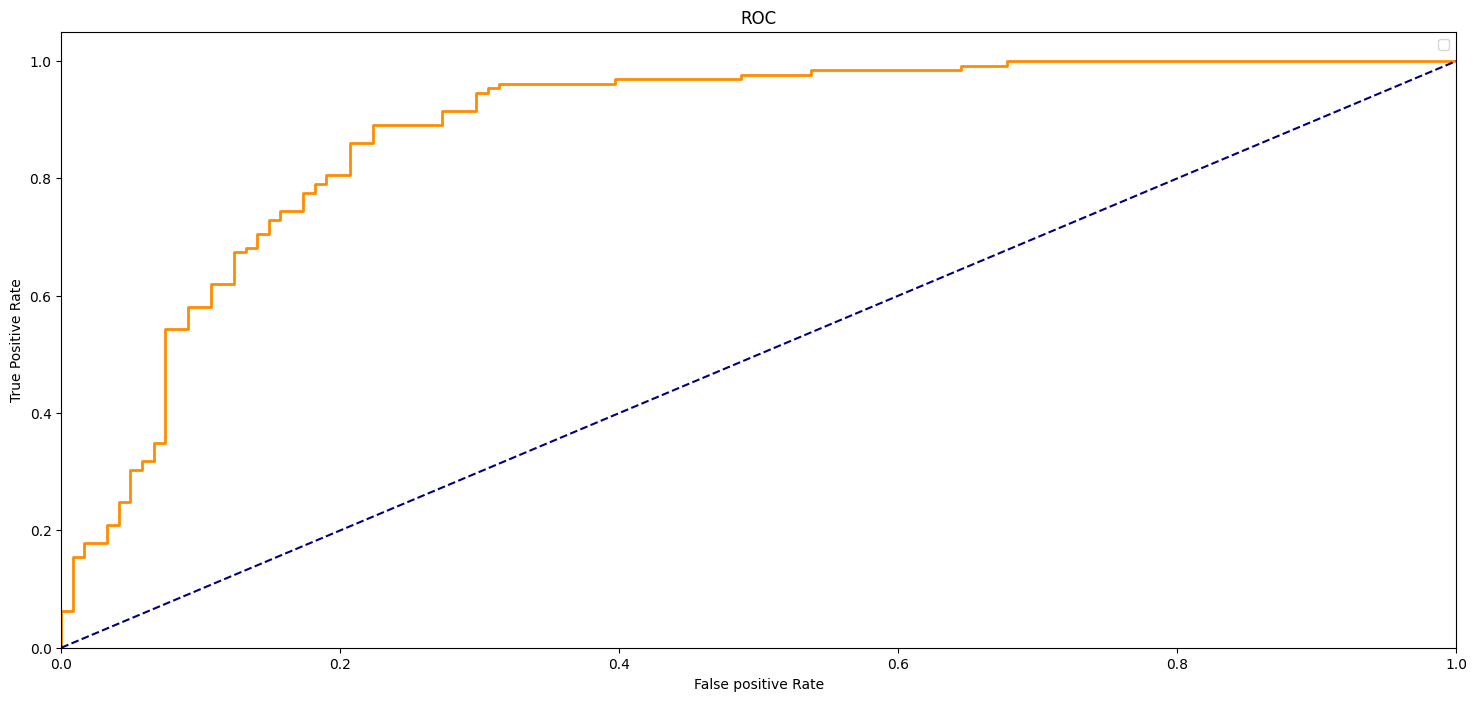

In [19]:
#plotting the roc_auc curve
fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)
roc_auc=auc(fpr,tpr)
display(roc_auc)
plt.figure(figsize=(18,8))
plt.plot(fpr,tpr,color='darkorange',linewidth=2)
plt.plot([0,1],[0,1],color='navy',linestyle='--')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.xlabel("False positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC")
plt.legend()
plt.show()

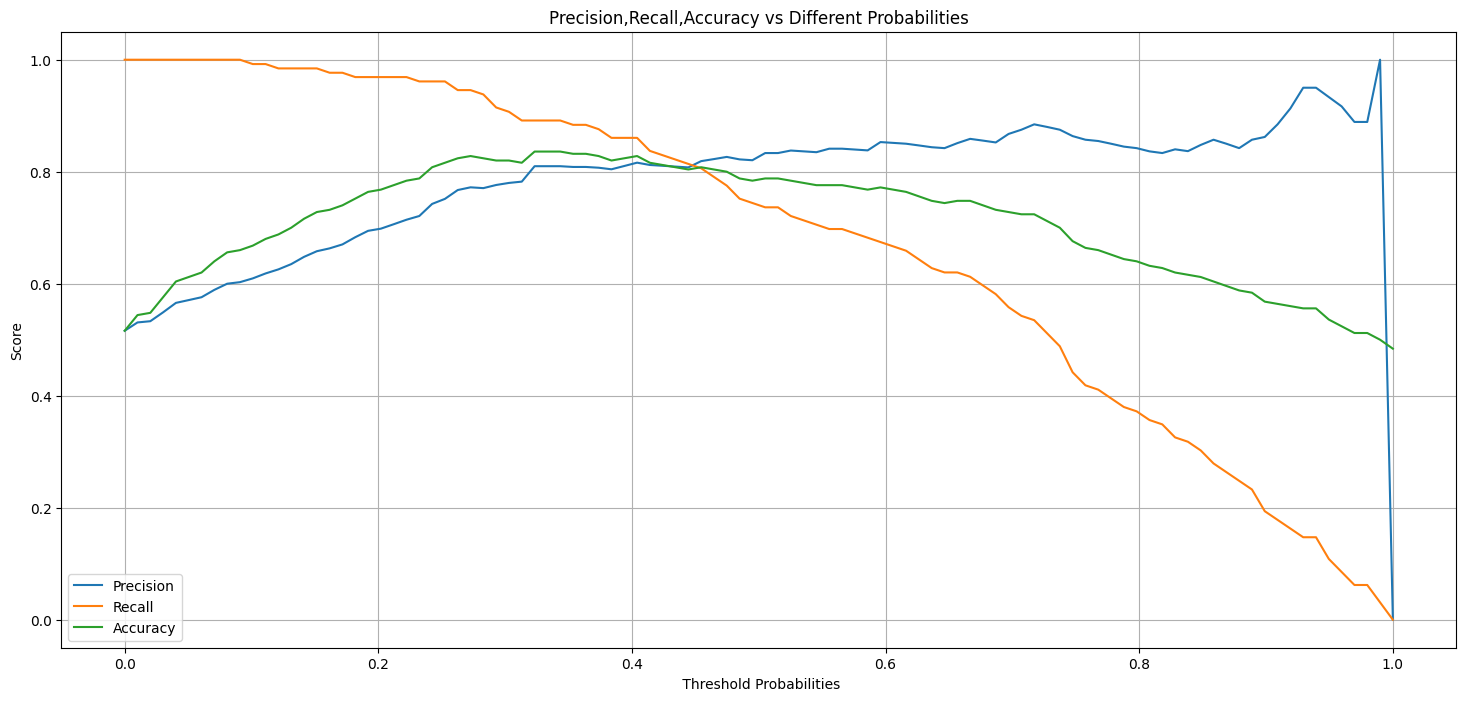

0.828

In [40]:
# Calculating precision ,recall and accuracy for different threshold probabilities
gen_threshold=np.linspace(0,1,100)
precisions=[]
recalls=[]
accuracys=[]
for i in gen_threshold:
    y_pred_threshold=(y_pred_proba>=i).astype(int)
    precision=precision_score(y_test,y_pred_threshold)
    recall=recall_score(y_test,y_pred_threshold)
    accuracy=accuracy_score(y_test,y_pred_threshold)
    precisions.append(precision)
    recalls.append(recall)
    accuracys.append(accuracy)
# Plotting the Graph
plt.figure(figsize=(18,8))
plt.plot(gen_threshold,precisions,label='Precision')
plt.plot(gen_threshold,recalls,label='Recall')
plt.plot(gen_threshold,accuracys,label='Accuracy')
plt.xlabel(" Threshold Probabilities")
plt.ylabel("Score")
plt.title("Precision,Recall,Accuracy vs Different Probabilities")
plt.grid(True)
plt.legend()
plt.show()
new_pred_level=np.where(y_pred_proba>0.4,1,0)
confusion_matrix(y_test,new_pred_level)
new_acc=accuracy_score(y_test,new_pred_level)
display(new_acc)